Load Iris Dataset using the reference link given in HW Assignment

In [767]:
from sklearn import datasets
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

# M1_Python ML Basics.ipynb file reference 
# Load the Iris dataset which is mentioned in the reference link
df_iris = pd.read_csv('iris.data',header=None,encoding='utf-8')     
#print(df_iris.head())

Choosing linearly separable classes 'Iris-setosa' and 'Iris-versicolor'

In [768]:
df_filtered = df_iris[df_iris[4].isin(['Iris-setosa','Iris-versicolor'])]

In [769]:
# 2 features sepal length and petal length with linearly separable classes
def FeatureWith2Classes():
    X = df_filtered[[0,2]].values
    Y = df_filtered[4].values
    Y = np.where(Y == 'Iris-setosa',-1,1)
    return X,Y
# 3 features sepal length and petal length and sepal width with linearly separable classes
def Feature3With2Classes():
    X = df_filtered[[0,1,2]].values
    Y = df_filtered[4].values
    Y = np.where(Y == 'Iris-setosa',-1,1)
    return X,Y
# 4 features sepal length and petal length and sepal width petal width with linearly separable classes
def AllFeatureWith2Classes():
    X = df_filtered[[0,1,2,3]].values
    Y = df_filtered[4].values
    Y = np.where(Y == 'Iris-setosa',-1,1)
    return X,Y


Plotting sepal length and Petal length with 2 classes Setosa and Versicolor

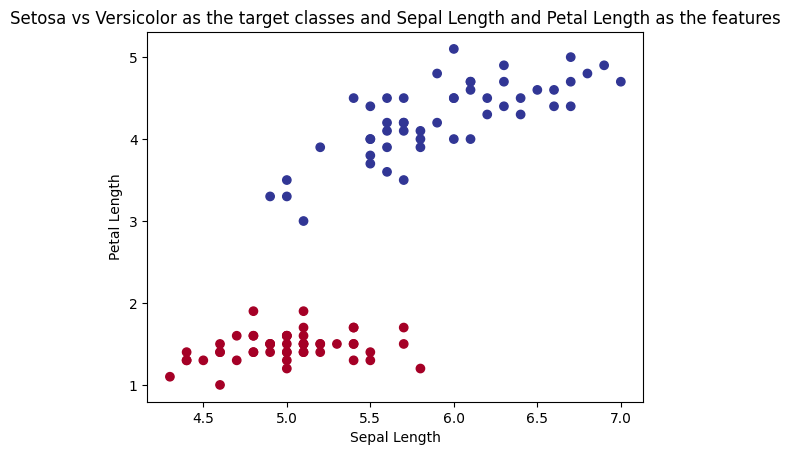

In [770]:

X,Y = FeatureWith2Classes()
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.RdYlBu)
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Setosa vs Versicolor as the target classes and Sepal Length and Petal Length as the features')
plt.show()

Plotting sepal length ,Sepal Width, Petal length with 2 classes Setosa and Versicolor

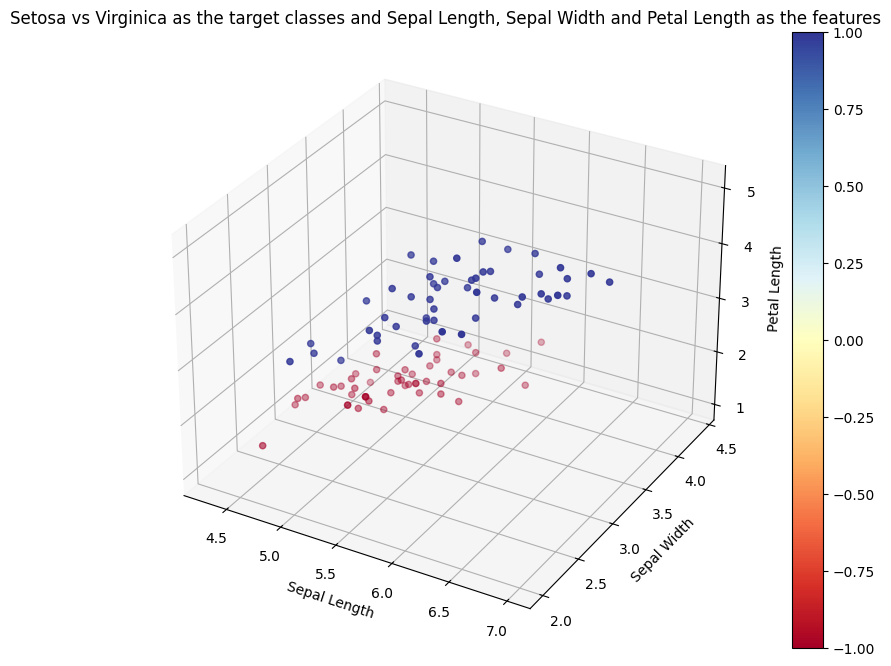

In [771]:
X,Y = Feature3With2Classes()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=Y, cmap=plt.cm.RdYlBu)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('Setosa vs Virginica as the target classes and Sepal Length, Sepal Width and Petal Length as the features')

plt.colorbar(scatter)
plt.show()

Plotting sepal length ,Sepal Width, Petal length,Petal Width with 2 classes Setosa and Versicolor

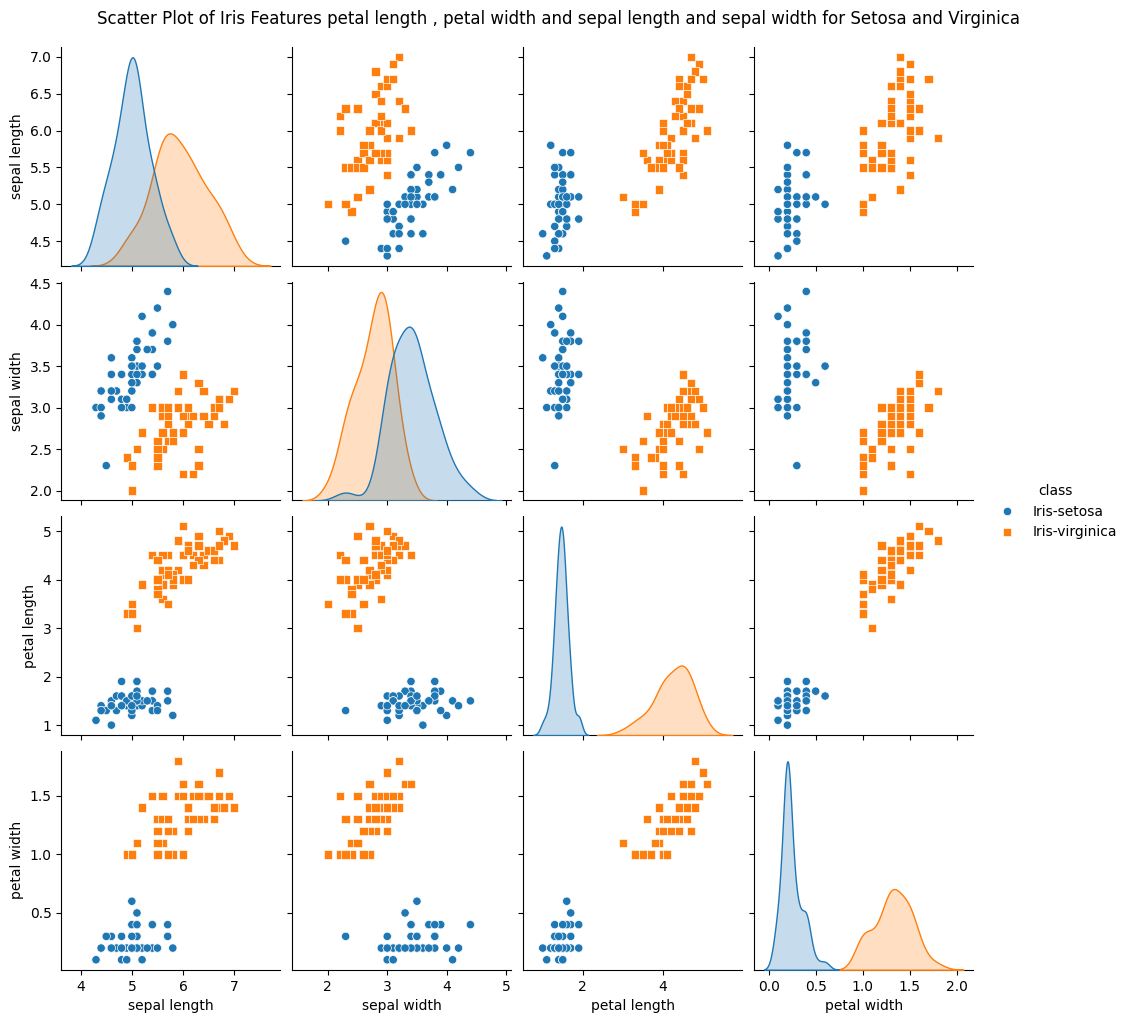

In [772]:
X, Y = AllFeatureWith2Classes()

df_plot = pd.DataFrame(X, columns=['sepal length', 'sepal width', 'petal length', 'petal width'])
df_plot['class'] = np.where(Y == -1, 'Iris-setosa', 'Iris-virginica')

sns.pairplot(df_plot, hue="class", diag_kind='kde', markers=["o", "s"])
plt.suptitle('Scatter Plot of Iris Features petal length , petal width and sepal length and sepal width for Setosa and Virginica', y=1.02)  # y=1.0
# Show the plot
plt.show()


In [773]:
class Perceptron(object):
    def __init__(self, eta=0.01, n_iter=50, random_state=1): 
        self.eta = eta 
        self.n_iter = n_iter
        self.random_state=random_state
    def fit(self, X, y):
        #X = np.asarray(X)
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size = 1 + X.shape[1]) 
        self.errors_ = [] 
        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y): 
                update = self.eta * (target - self.predict(xi)) 
                update = update.item()
                self.w_[1:] += update * xi 
                self.w_[0] += update 
                errors += int(update != 0.0) 
            self.errors_.append(errors) 
        return self
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]
    def predict (self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)

In [774]:
class AdalineGD(object):
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        #y = np.array(y).ravel() 
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []
        
        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        return X  

    def predict(self, X):
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)


In [775]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


input_X,output_Y  =  FeatureWith2Classes()


X_train, X_test, y_train, y_test = train_test_split(input_X, output_Y, test_size=0.3, random_state=42)

scaler = StandardScaler()
scaler.fit(input_X)
X_train_standard = scaler.transform(X_train)
X_test_standard = scaler.transform(X_test)


perceptt = Perceptron(eta=0.001 ,n_iter= 10)
perceptt.fit(X_train_standard,y_train)
y_pred_perceptron = perceptt.predict(X_test_standard)



adaline = AdalineGD(eta=0.001 ,n_iter= 10)
adaline.fit(X_train_standard,y_train)
y_pred_adaline = adaline.predict(X_test_standard)

# Calculate accuracy for perceptron and adaline
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
accuracy_adaline = accuracy_score(y_test, y_pred_adaline)

print(f"Accuracy for preceptron 2 features and 2 classes: {accuracy_perceptron*100:.2f}")
print(f"Accuracy for adaline 2 features and 2 classes: {accuracy_adaline*100:.2f}")


Accuracy for preceptron 2 features and 2 classes: 100.00
Accuracy for adaline 2 features and 2 classes: 100.00


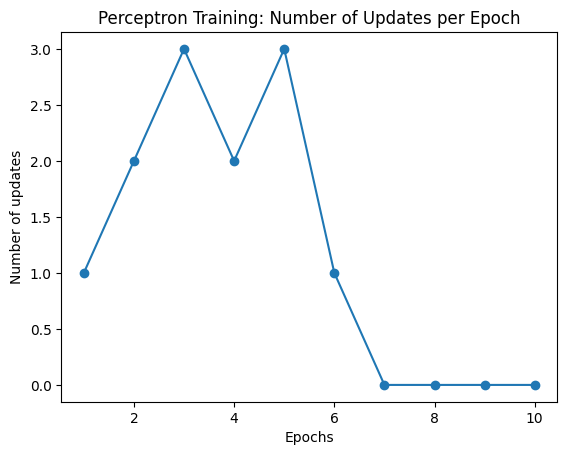

In [776]:
ppn = Perceptron(eta=0.001, n_iter=10)
ppn.fit(X, y)
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.title('Perceptron Training: Number of Updates per Epoch')
plt.show()

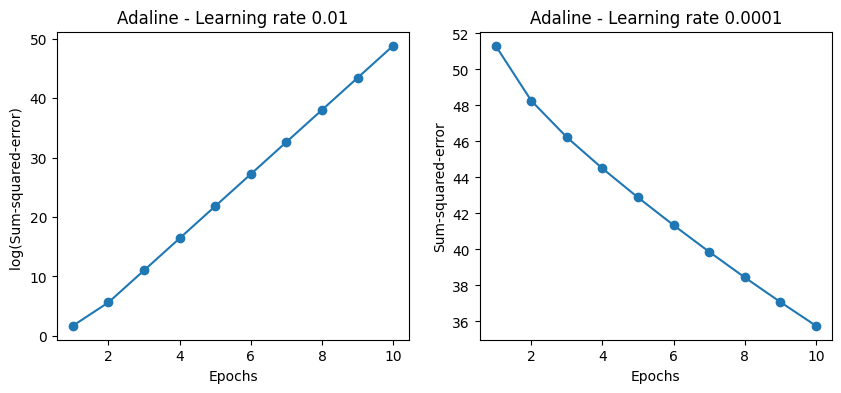

In [777]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
adal = AdalineGD(n_iter=10, eta=0.1).fit(X, y)
ax[0].plot(range(1, len(adal.cost_) + 1), np.log10(adal.cost_), marker='o') 
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel ('log(Sum-squared-error) ')
ax[0].set_title('Adaline - Learning rate 0.01')
ada2 = AdalineGD(n_iter=10, eta=0.0001).fit(X, y) 
ax[1].plot(range(1, len(ada2.cost_) + 1), ada2.cost_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel ('Sum-squared-error')
ax[1].set_title('Adaline - Learning rate 0.0001') 
plt.show()

In [778]:
# for 3 features and 2 linearly separable classes
input_X,output_Y  =  Feature3With2Classes()



X_train, X_test, y_train, y_test = train_test_split(input_X, output_Y, test_size=0.3, random_state=42)


scaler = StandardScaler()
scaler.fit(input_X)
X_train_standard = scaler.transform(X_train)
X_test_standard = scaler.transform(X_test)


perceptt = Perceptron(eta=0.01 ,n_iter= 10)
perceptt.fit(X_train_standard,y_train)
y_pred_perceptron = perceptt.predict(X_test_standard)



adaline = AdalineGD(eta=0.001 ,n_iter= 10)
adaline.fit(X_train_standard,y_train)
y_pred_adaline = adaline.predict(X_test_standard)

# Calculate accuracy for perceptron and adaline
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
accuracy_adaline = accuracy_score(y_test, y_pred_adaline)

print(f"Accuracy for preceptron 3 features and 2 classes: {accuracy_perceptron*100:.2f}")
print(f"Accuracy for adaline 3 features and 2 classes: {accuracy_adaline*100:.2f}")


Accuracy for preceptron 3 features and 2 classes: 100.00
Accuracy for adaline 3 features and 2 classes: 100.00


In [779]:
# for 4 features and 2 linearly separable classes
input_X,output_Y  =  AllFeatureWith2Classes()



X_train, X_test, y_train, y_test = train_test_split(input_X, output_Y, test_size=0.3, random_state=42)

scaler = StandardScaler()
scaler.fit(input_X)
X_train_standard = scaler.transform(X_train)
X_test_standard = scaler.transform(X_test)

perceptt = Perceptron(eta=0.001 ,n_iter= 10)
perceptt.fit(X_train_standard,y_train)
y_pred_perceptron = perceptt.predict(X_test_standard)


adaline = AdalineGD(eta=0.001 ,n_iter= 10)
adaline.fit(X_train_standard,y_train)
y_pred_adaline = adaline.predict(X_test_standard)

# Calculate accuracy for perceptron and adaline
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
accuracy_adaline = accuracy_score(y_test, y_pred_adaline)

print(f"Accuracy for preceptron 4 features and 2 classes: {accuracy_perceptron*100:.2f}")
print(f"Accuracy for adaline 4 features and 2 classes: {accuracy_adaline*100:.2f}")

Accuracy for preceptron 4 features and 2 classes: 100.00
Accuracy for adaline 4 features and 2 classes: 100.00


Choosing non-linearly separable classes 'Iris-virginica' and 'Iris-versicolor'

In [780]:
df_filtered_non = df_iris[df_iris[4].isin(['Iris-virginica','Iris-versicolor'])]

In [781]:
# 2 features sepal length and petal length with non-linearly separable classes
def Non_FeatureWith2Classes():
    X = df_filtered_non[[0,2]].values
    Y = df_filtered_non[4].values
    Y = np.where(Y == 'Iris-virginica',-1,1)
    return X,Y
# 3 features sepal length and petal length and sepal width with non-linearly separable classes
def Non_Feature3With2Classes():
    X = df_filtered_non[[0,1,2]].values
    Y = df_filtered_non[4].values
    Y = np.where(Y == 'Iris-virginica',-1,1)
    return X,Y
# 4 features sepal length and petal length and sepal width petal width with non-linearly separable classes
def Non_AllFeatureWith2Classes():
    X = df_filtered_non[[0,1,2,3]].values
    Y = df_filtered_non[4].values
    Y = np.where(Y == 'Iris-virginica',-1,1)
    return X,Y


Plotting Sepal length and petal length with 2 classes which are non-linearly separable

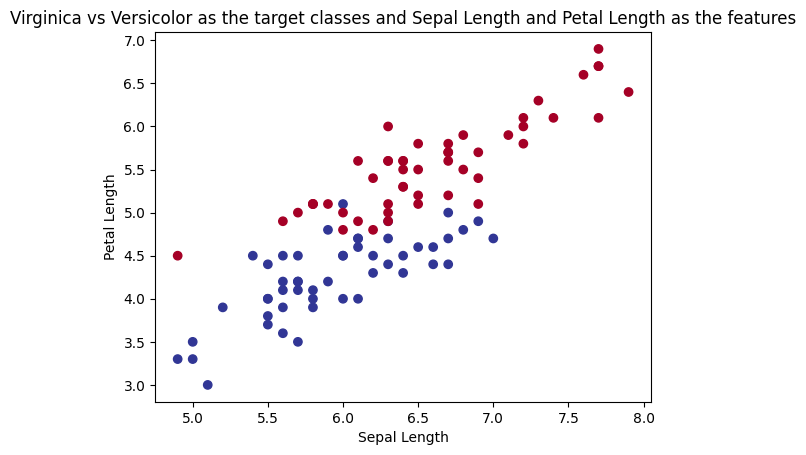

In [782]:
X,Y = Non_FeatureWith2Classes()
#print(X,Y)
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.RdYlBu)
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Virginica vs Versicolor as the target classes and Sepal Length and Petal Length as the features')
plt.show()

Plotting Sepal length ,sepal width and petal length with 2 classes which are non-linearly separable

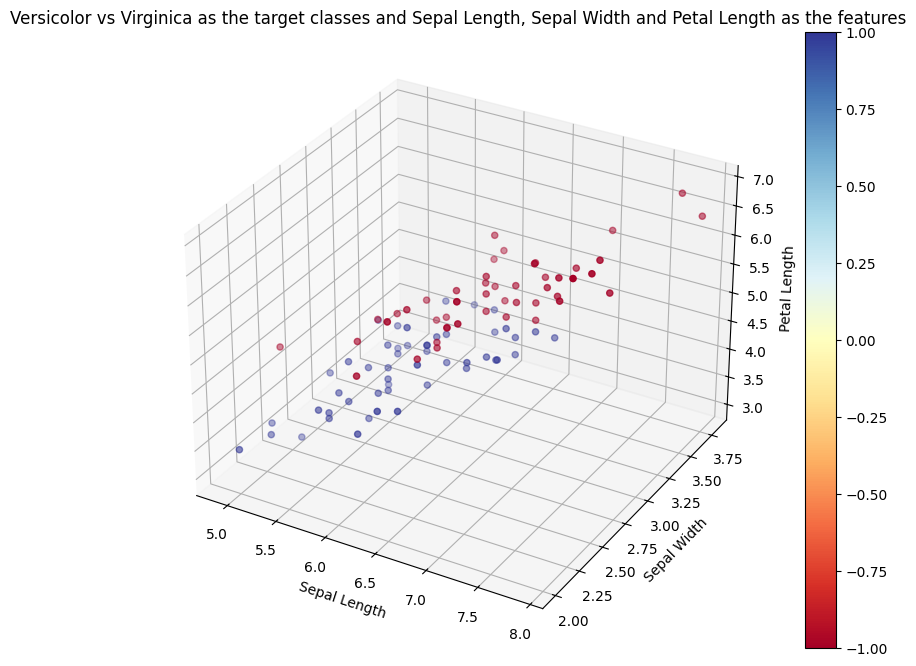

In [783]:
X,Y = Non_Feature3With2Classes()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=Y, cmap=plt.cm.RdYlBu)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('Versicolor vs Virginica as the target classes and Sepal Length, Sepal Width and Petal Length as the features')

plt.colorbar(scatter)
plt.show()

Plotting Sepal length ,sepal width, petal length and petal width with 2 classes which are non-linearly separable

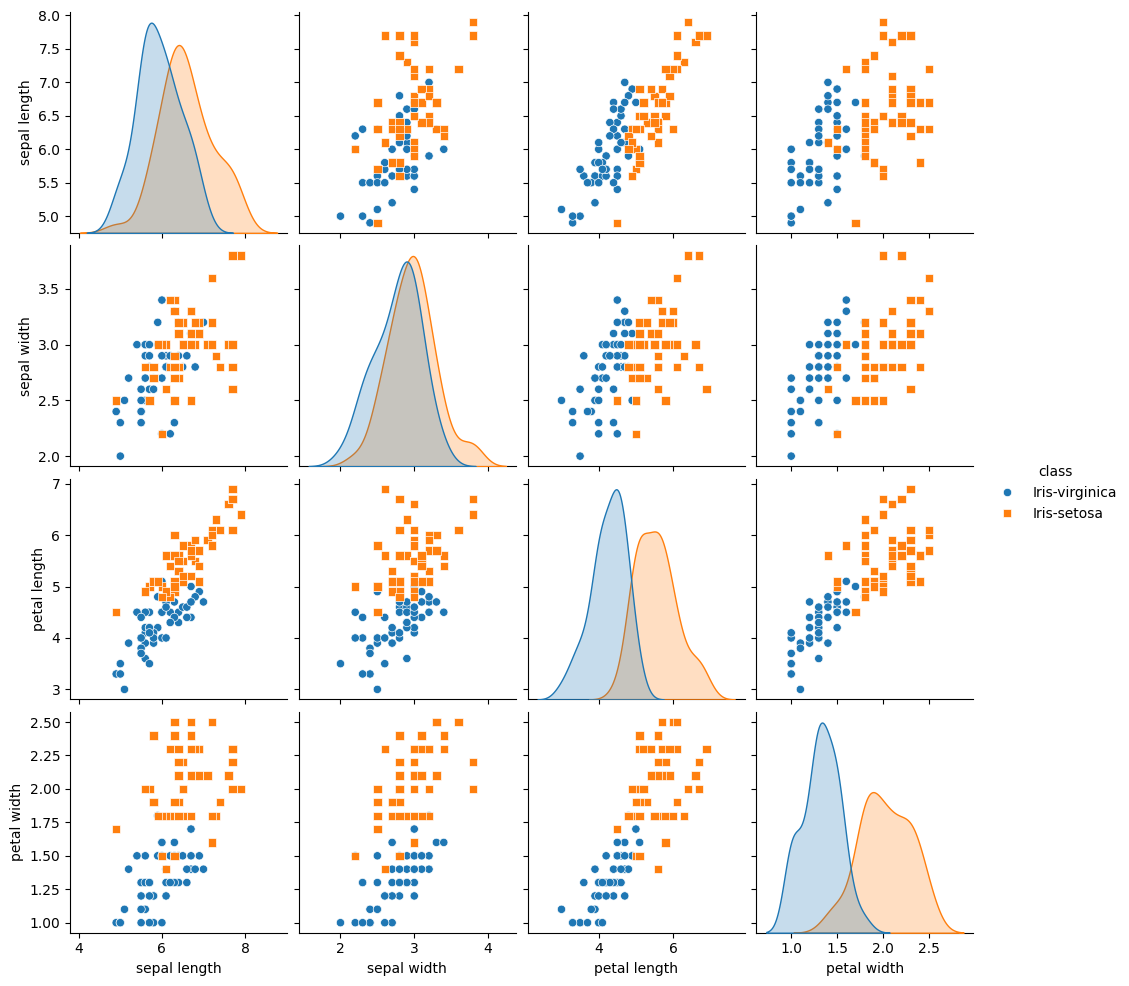

In [784]:
X, Y = Non_AllFeatureWith2Classes()

df_plot = pd.DataFrame(X, columns=['sepal length', 'sepal width', 'petal length', 'petal width'])
df_plot['class'] = np.where(Y == -1, 'Iris-setosa', 'Iris-virginica')

sns.pairplot(df_plot, hue="class", diag_kind='kde', markers=["o", "s"])

# Show the plot
plt.show()


In [785]:
# for 2 features and 2 non-linearly separable classes
input_X,output_Y  =  Non_FeatureWith2Classes()

X_train, X_test, y_train, y_test = train_test_split(input_X, output_Y, test_size=0.3, random_state=42)


scaler = StandardScaler()
scaler.fit(input_X)
X_train_standard = scaler.transform(X_train)
X_test_standard = scaler.transform(X_test)

perceptt = Perceptron(eta=0.001 ,n_iter= 100)
perceptt.fit(X_train_standard,y_train)
y_pred_perceptron = perceptt.predict(X_test_standard)


adaline = AdalineGD(eta=0.001 ,n_iter= 100)
adaline.fit(X_train_standard,y_train)
y_pred_adaline = adaline.predict(X_test_standard)

# Calculate accuracy for perceptron and adaline
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
accuracy_adaline = accuracy_score(y_test, y_pred_adaline)

print(f"Accuracy for preceptron 2 features and 2 classes non-linearly separable: {accuracy_perceptron*100:.2f}")
print(f"Accuracy for adaline 2 features and 2 classes non-linearly separable: {accuracy_adaline*100:.2f}")

Accuracy for preceptron 2 features and 2 classes non-linearly separable: 86.67
Accuracy for adaline 2 features and 2 classes non-linearly separable: 86.67


In [786]:
# for 3 features and 2 non-linearly separable classes
input_X,output_Y  =  Non_Feature3With2Classes()

X_train, X_test, y_train, y_test = train_test_split(input_X, output_Y, test_size=0.3, random_state=42)

scaler = StandardScaler()
scaler.fit(input_X)
X_train_standard = scaler.transform(X_train)
X_test_standard = scaler.transform(X_test)

perceptt = Perceptron(eta=0.001 ,n_iter= 100)
perceptt.fit(X_train_standard,y_train)
y_pred_perceptron = perceptt.predict(X_test_standard)


adaline = AdalineGD(eta=0.001 ,n_iter= 100)
adaline.fit(X_train_standard,y_train)
y_pred_adaline = adaline.predict(X_test_standard)

# Calculate accuracy for perceptron and adaline
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
accuracy_adaline = accuracy_score(y_test, y_pred_adaline)

print(f"Accuracy for preceptron 3 features and 2 classes non-linearly separable: {accuracy_perceptron*100:.2f}")
print(f"Accuracy for adaline 3 features and 2 classes non-linearly separable: {accuracy_adaline*100:.2f}")

Accuracy for preceptron 3 features and 2 classes non-linearly separable: 86.67
Accuracy for adaline 3 features and 2 classes non-linearly separable: 86.67


In [788]:
# for 4 features and 2 non-linearly separable classes
input_X,output_Y  =  Non_AllFeatureWith2Classes()

X_train, X_test, y_train, y_test = train_test_split(input_X, output_Y, test_size=0.3, random_state=42)

scaler = StandardScaler()
scaler.fit(input_X)
X_train_standard = scaler.transform(X_train)
X_test_standard = scaler.transform(X_test)


perceptt = Perceptron(eta=0.001 ,n_iter= 100)
perceptt.fit(X_train_standard,y_train)
y_pred_perceptron = perceptt.predict(X_test_standard)


adaline = AdalineGD(eta=0.001 ,n_iter= 100)
adaline.fit(X_train_standard,y_train)
y_pred_adaline = adaline.predict(X_test_standard)

# Calculate accuracy for perceptron and adaline
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
accuracy_adaline = accuracy_score(y_test, y_pred_adaline)

print(f"Accuracy for preceptron 4 features and 2 classes non-linearly separable: {accuracy_perceptron*100:.2f}")
print(f"Accuracy for adaline 4 features and 2 classes non-linearly separable: {accuracy_adaline*100:.2f}")

Accuracy for preceptron 4 features and 2 classes non-linearly separable: 83.33
Accuracy for adaline 4 features and 2 classes non-linearly separable: 86.67


# Summary
After analyzing both accuracy scores of Adaline and perceptron and plots for linearly and non-linearly separable classes with features of the iris dataset we can conclude with the below findings:
1) For linearly separable classes (Setosa and versicolor) the accuracy for the perceptron is 100%.
I.e. in the case of linearly separable data, the Perceptron achieves 100% accuracy, meaning it perfectly classifies the data into the two classes in a fixed number of iterations. Thus guaranteeing the finding of a perfect separation decision boundary/hyperplane when the dataset is linearly separable. Also, perceptron classifies the given input and if misclassified then only updates the weight 
For Adaline as well the accuracy is 100%. Since Adaline makes use of a gradient descent approach, which in turn is highly sensitive to the learning rate, making the learning rate higher can cause the weights to deviate without reaching the converging point while choosing a very small learning rate will lead to a very slow converging or getting stuck at a sub-optimal solution.
Also, Gradient descent needs enough iterations to converge to an optimal solution, especially if the learning rate is small and also calculates the error first and then updates the weights in order to minimize the error function.
Thus we can conclude that Both Perceptron and Adaline are linear classifiers and they work well on linearly separable data i.e Linearly separable data meaning there exists a hyperplane (line in 2d or plane in 3d) that can perfectly separate the classes mentioned. Both algorithms are capable of finding such a hyperplane under ideal and proper conditions. Hence with proper feature scaling, learning rates (r), and an appropriate no of training iterations(n_iter), both the Perceptron and Adaline are also reaching the optimal solution for linearly separable data.

3) For non-linearly separable classes(verginica and versicolor) meaning they are not perfectly separable the accuracy for the perceptron is around 83-84% and for adaline around 86-87% indicating that the perceptron and adaline both are linear classifiers and work well on linearly separable data. However, the Adaline algorithm focuses on minimizing the error objective ie mean squared error during training the data and producing smoothening of weight updates rather than just misclassifying which is slightly better than the accuracy of perceptron, and a slight improvement is found in its performance on non-linearly separable datasets, leading to being it quite similar or having almost better accuracy as compared to the performance of perceptron.
Also perceptron behavior for the dataset having non-linearly separable classes (Iris-versicolor and Iris-virginica), the Perceptron is still classifying a large number of data points correctly due to the distribution of features in the dataset, even though it's not finding an ideal linear decision boundary. Thus showing that perceptron is consistent with some of the segments of the data which are linearly separable while others are not.


4) Hence we can deduce from the above 2 points that the Perceptron and Adaline work well on the linearly separable dataset, but for non-linearly separable dataset ie for certain classes for the Iris dataset in this case, it's trying hard to find a sub-optimal / optimal solution as both can only produce a linear decision boundary. Adaline also focuses on finding a linear decision boundary and thus faces similar problems as the Perceptron on non-linearly separable data. Thus, the accuracy for the non-linearly separable data reflects the fact that neither the perceptron model nor the adaline model can perfectly separate these classes with a linear decision boundary. Even, they can still classify a significant portion of the data correctly because of the way feature distributions are overlapping from the plot given above.

Thus I believe if we want to improve Adaline's performance we can make use of the feature engineering to handle non-linear datasets better or switch to a more advanced model like Logistic Regression, SVM, DecisionTree, or Neural networks.
